In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# Set random seed for reproducibility
# This ensures we get the same random numbers every time we run the code
torch.manual_seed(42)
np.random.seed(42)

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")

Libraries imported successfully!
PyTorch version: 2.12.0+cu130


## Generate Synthetic Data

In [2]:
# Define the "true" underlying relationship: y = weight * x + bias
# These are the values our model should learn
weight_true = 0.7  # The true slope of the line
bias_true = 0.3    # The true y-intercept

# Create input features: values from 0 to 1 (exclusive) with step 0.02
# This creates 50 data points (0, 0.02, 0.04, ..., 0.98)
X = torch.arange(0, 1, 0.02)

# Add a dimension to make it a column vector (shape: [50] -> [50, 1])
# PyTorch models expect inputs as 2D tensors: [batch_size, features]
X = X.unsqueeze(dim=1)

# Generate target values using the true linear relationship
# y = 0.7 * x + 0.3 (perfect linear relationship with no noise)
y = weight_true * X + bias_true

print(f"Data shape: X={X.shape}, y={y.shape}")
print(f"First 5 samples:\nX: {X[:5].squeeze()}\ny: {y[:5].squeeze()}")
print(f"True relationship: y = {weight_true} * x + {bias_true}")

Data shape: X=torch.Size([50, 1]), y=torch.Size([50, 1])
First 5 samples:
X: tensor([0.0000, 0.0200, 0.0400, 0.0600, 0.0800])
y: tensor([0.3000, 0.3140, 0.3280, 0.3420, 0.3560])
True relationship: y = 0.7 * x + 0.3


## Train / Test Split

In [3]:
# Determine split point: 80% for training, 20% for testing
train_split = int(0.8 * len(X))

# Split the data into training and testing sets
# First 80% for training, remaining 20% for testing
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

print(f"Total samples: {len(X)}")
print(f"Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Testing samples: {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")
print(f"Training range: X from {X_train[0].item():.2f} to {X_train[-1].item():.2f}")
print(f"Testing range: X from {X_test[0].item():.2f} to {X_test[-1].item():.2f}")

Total samples: 50
Training samples: 40 (80%)
Testing samples: 10 (20%)
Training range: X from 0.00 to 0.78
Testing range: X from 0.80 to 0.98


## Dataloaders

In [4]:
# TensorDataset: Combines features and targets into a single dataset object
# This allows us to access paired (X, y) samples together
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# DataLoader: Creates an iterable over the dataset
# batch_size=8: Process 8 samples at a time (mini-batch training)
# shuffle=True: Randomize order each epoch (prevents learning order patterns)
# shuffle=False: Keep order consistent for reproducible evaluation
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

# Verify the dataloaders work
sample_batch_X, sample_batch_y = next(iter(train_loader))
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of testing batches: {len(test_loader)}")
print(f"Sample batch shape: X={sample_batch_X.shape}, y={sample_batch_y.shape}")
print(f"Sample batch X: {sample_batch_X.squeeze()}")
print(f"Sample batch y: {sample_batch_y.squeeze()}")

Number of training batches: 5
Number of testing batches: 2
Sample batch shape: X=torch.Size([8, 1]), y=torch.Size([8, 1])
Sample batch X: tensor([0.1600, 0.2800, 0.3000, 0.1800, 0.2000, 0.7000, 0.0800, 0.7600])
Sample batch y: tensor([0.4120, 0.4960, 0.5100, 0.4260, 0.4400, 0.7900, 0.3560, 0.8320])


## Define the Model

In [5]:
class LinearRegressionModel(nn.Module):
    """
    A simple linear regression model: y = weight * x + bias
    Inherits from nn.Module - PyTorch's base class for all neural networks
    """
    
    def __init__(self):
        """
        Constructor: Initialize the model's parameters
        """
        # Call parent class constructor (required for proper initialization)
        super().__init__()
        
        # Define learnable parameters using nn.Parameter
        # nn.Parameter wraps a tensor and tells PyTorch it should be trained
        # torch.randn(1): Initialize with random value from normal distribution
        # requires_grad=True: PyTorch will track gradients for this tensor
        self.weight = nn.Parameter(torch.randn(1, requires_grad=True))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True))
        
        # Print initial parameter values (useful for debugging)
        print(f"Initial weight: {self.weight.item():.4f}")
        print(f"Initial bias: {self.bias.item():.4f}")
    
    def forward(self, x):
        """
        Forward pass: Define how input x is transformed to output
        This implements the linear equation: y = w*x + b
        
        Args:
            x: Input tensor of shape [batch_size, 1]
            
        Returns:
            Predictions of shape [batch_size, 1]
        """
        return self.weight * x + self.bias

# Test the model with a sample input
test_model = LinearRegressionModel()
test_input = torch.tensor([[0.5]])
test_output = test_model(test_input)
print(f"\nTest forward pass: x=0.5 -> y={test_output.item():.4f}")

Initial weight: 0.2345
Initial bias: 0.2303

Test forward pass: x=0.5 -> y=0.3476


## Custom Loss Functions

In [6]:
class MeanAbsoluteError(nn.Module):
    """
    Mean Absolute Error (MAE) loss function
    Measures the average absolute difference between predictions and targets
    Less sensitive to outliers than MSE
    """
    
    def forward(self, predictions, targets):
        """
        Args:
            predictions: Model outputs
            targets: Ground truth values
        Returns:
            Scalar loss value
        """
        # Calculate absolute differences
        absolute_errors = torch.abs(predictions - targets)
        # Average over all samples
        return torch.mean(absolute_errors)


class HuberLoss(nn.Module):
    """
    Huber Loss: Combines MAE and MSE
    - For small errors (< delta): Uses quadratic (MSE-like) - smooth and differentiable
    - For large errors (>= delta): Uses linear (MAE-like) - less sensitive to outliers
    """
    
    def __init__(self, delta=1.0):
        """
        Args:
            delta: Threshold between quadratic and linear regions
        """
        super().__init__()
        self.delta = delta
    
    def forward(self, predictions, targets):
        """
        Calculate Huber loss
        
        Args:
            predictions: Model outputs
            targets: Ground truth values
        Returns:
            Scalar loss value
        """
        # Calculate residuals (errors)
        residuals = predictions - targets
        
        # Take absolute value of residuals
        abs_res = torch.abs(residuals)
        
        # Quadratic part for small errors: 0.5 * error^2
        quadratic = 0.5 * residuals**2
        
        # Linear part for large errors: delta * |error| - 0.5 * delta^2
        linear = self.delta * abs_res - 0.5 * self.delta**2
        
        # Choose between quadratic and linear based on error magnitude
        # torch.where(condition, value_if_true, value_if_false)
        loss = torch.where(abs_res <= self.delta, quadratic, linear)
        
        # Return mean loss over the batch
        return torch.mean(loss)

# Test the loss functions
test_pred = torch.tensor([1.0, 2.0, 3.0])
test_target = torch.tensor([1.2, 2.1, 2.8])

mae = MeanAbsoluteError()
huber = HuberLoss(delta=1.0)

print("Testing loss functions:")
print(f"MAE loss: {mae(test_pred, test_target).item():.4f}")
print(f"Huber loss: {huber(test_pred, test_target).item():.4f}")

Testing loss functions:
MAE loss: 0.1667
Huber loss: 0.0150


## Instantiate Model, Loss, Optimizer

In [7]:
# Create an instance of our model
model = LinearRegressionModel()

# Choose loss function - UNCOMMENT THE ONE YOU WANT TO USE

# Option 1: PyTorch's built-in L1Loss (Mean Absolute Error)
loss_fn = nn.L1Loss()
print(f"Using loss: PyTorch L1Loss (MAE)")

# Option 2: Use our custom MAE (uncomment to use)
# loss_fn = MeanAbsoluteError()
# print(f"Using loss: Custom MeanAbsoluteError")

# Option 3: Use Huber Loss with delta=1.0 (uncomment to use)
# loss_fn = HuberLoss(delta=1.0)
# print(f"Using loss: HuberLoss (delta=1.0)")

# Choose optimizer: Stochastic Gradient Descent
# model.parameters(): Tells optimizer which tensors to update
# lr=0.01: Learning rate - step size for parameter updates
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

print(f"Optimizer: {optimizer.__class__.__name__} with lr=0.01")
print(f"Parameters to train: {sum(p.numel() for p in model.parameters())}")

Initial weight: -1.1229
Initial bias: -0.1863
Using loss: PyTorch L1Loss (MAE)
Optimizer: SGD with lr=0.01
Parameters to train: 2


## Training Loop

In [8]:
# Number of complete passes through the entire dataset
epochs = 300

# Lists to store loss values for tracking progress
train_losses = []
test_losses = []

print("\nStarting training...")
print("-" * 60)

# Loop over each epoch
for epoch in range(epochs):
    
    # ===== TRAINING PHASE =====
    
    # Set model to training mode
    # (Important for dropout/batch norm - not critical here but good practice)
    model.train()
    
    # Initialize accumulator for training loss this epoch
    train_loss = 0.0
    
    # Iterate over mini-batches from the training dataloader
    for X_batch, y_batch in train_loader:
        # X_batch: Features for this batch [8, 1]
        # y_batch: Targets for this batch [8, 1]
        
        # Forward pass: Compute predictions for this batch
        predictions = model(X_batch)
        
        # Calculate loss: Compare predictions to ground truth
        loss = loss_fn(predictions, y_batch)
        
        # Step 1: Clear old gradients from previous iteration
        # IMPORTANT: Without this, gradients would accumulate!
        optimizer.zero_grad()
        
        # Step 2: Compute gradients via backpropagation
        # This calculates ∂loss/∂weight and ∂loss/∂bias
        loss.backward()
        
        # Step 3: Update model parameters
        # weight = weight - learning_rate * gradient_weight
        # bias = bias - learning_rate * gradient_bias
        optimizer.step()
        
        # Accumulate loss (convert to Python float with .item())
        train_loss += loss.item()
    
    # Calculate average training loss for this epoch
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # ===== TESTING PHASE =====
    
    # Set model to evaluation mode
    # This disables dropout and freezes batch norm statistics
    model.eval()
    
    # Initialize accumulator for test loss
    test_loss = 0.0
    
    # Disable gradient computation for evaluation (saves memory and speeds up)
    # torch.inference_mode() is more optimized than torch.no_grad()
    with torch.inference_mode():
        # Iterate over test data
        for X_batch, y_batch in test_loader:
            # Forward pass (no gradients needed)
            predictions = model(X_batch)
            
            # Calculate loss
            loss = loss_fn(predictions, y_batch)
            
            # Accumulate loss
            test_loss += loss.item()
    
    # Calculate average test loss
    avg_test_loss = test_loss / len(test_loader)
    test_losses.append(avg_test_loss)
    
    # Print progress every 50 epochs
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {avg_train_loss:.6f} | "
              f"Test Loss: {avg_test_loss:.6f}")

print("-" * 60)
print("Training complete!")


Starting training...
------------------------------------------------------------
Epoch [50/300] | Train Loss: 0.223136 | Test Loss: 0.561998
Epoch [100/300] | Train Loss: 0.137750 | Test Loss: 0.338852
Epoch [150/300] | Train Loss: 0.051408 | Test Loss: 0.126242
Epoch [200/300] | Train Loss: 0.005234 | Test Loss: 0.001316
Epoch [250/300] | Train Loss: 0.005235 | Test Loss: 0.014766
Epoch [300/300] | Train Loss: 0.005744 | Test Loss: 0.005108
------------------------------------------------------------
Training complete!


## Display Final Results

In [9]:
# Get the final learned parameters
final_weight = model.weight.item()
final_bias = model.bias.item()

print("Final learned parameters:")
print(f"  Learned weight: {final_weight:.6f} (True: {weight_true})")
print(f"  Learned bias: {final_bias:.6f} (True: {bias_true})")

# Calculate how close we got
weight_error = abs(final_weight - weight_true)
bias_error = abs(final_bias - bias_true)
print(f"\nErrors:")
print(f"  Weight error: {weight_error:.6f}")
print(f"  Bias error: {bias_error:.6f}")

# Calculate percentage accuracy
weight_accuracy = (1 - weight_error / abs(weight_true)) * 100
bias_accuracy = (1 - bias_error / abs(bias_true)) * 100
print(f"\nAccuracy:")
print(f"  Weight: {weight_accuracy:.2f}%")
print(f"  Bias: {bias_accuracy:.2f}%")

# Get predictions on test data for visualization
with torch.inference_mode():
    predictions = model(X_test).squeeze()

# Calculate test set metrics
with torch.inference_mode():
    test_predictions = model(X_test)
    mae = nn.L1Loss()(test_predictions, y_test)
    mse = nn.MSELoss()(test_predictions, y_test)

print(f"\nTest Set Metrics:")
print(f"  MAE: {mae.item():.6f}")
print(f"  MSE: {mse.item():.6f}")

Final learned parameters:
  Learned weight: 0.698844 (True: 0.7)
  Learned bias: 0.306172 (True: 0.3)

Errors:
  Weight error: 0.001156
  Bias error: 0.006172

Accuracy:
  Weight: 99.83%
  Bias: 97.94%

Test Set Metrics:
  MAE: 0.005143
  MSE: 0.000026


## Visualization

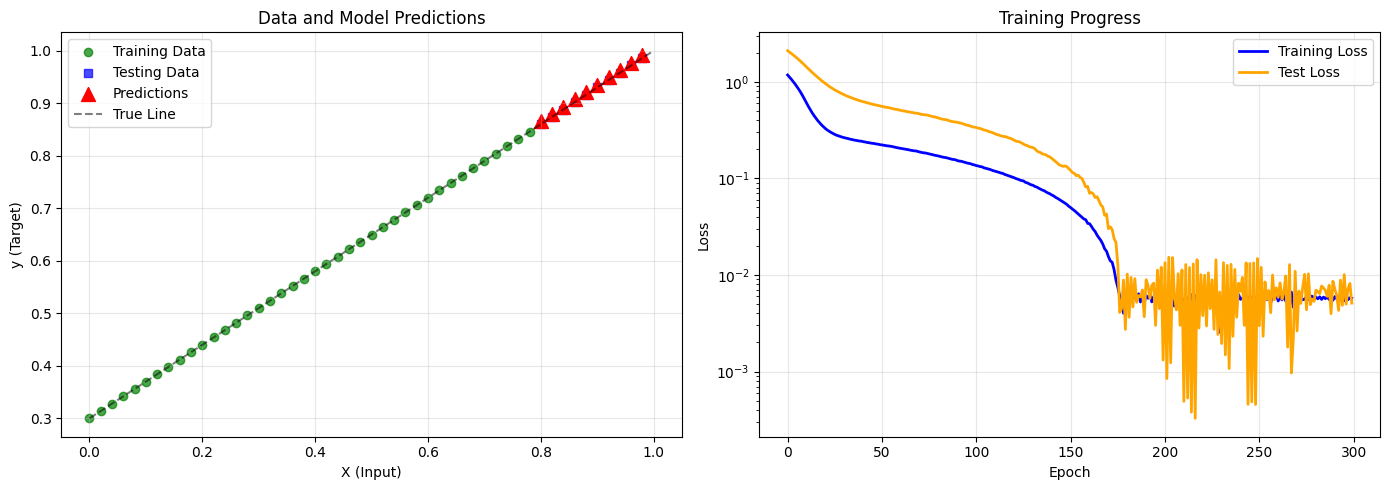

Visualization complete!


In [10]:
def plot_predictions(train_data, train_labels, test_data, test_labels, 
                     predictions=None, loss_history=None):
    """
    Create visualization plots for data and training progress
    
    Args:
        train_data: Training features
        train_labels: Training targets
        test_data: Testing features
        test_labels: Testing targets
        predictions: Model predictions on test data
        loss_history: Dictionary with 'train' and 'test' loss lists
    """
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # ---- Plot 1: Data and Predictions ----
    
    # Plot training data as green circles
    ax1.scatter(train_data, train_labels, c='green', 
                label='Training Data', marker='o', alpha=0.7)
    
    # Plot testing data as blue squares
    ax1.scatter(test_data, test_labels, c='blue', 
                label='Testing Data', marker='s', alpha=0.7)
    
    # If predictions are provided, overlay them as red triangles
    if predictions is not None:
        ax1.scatter(test_data, predictions, c='red', 
                    label='Predictions', marker='^', s=100)
    
    # Add the true line for reference
    x_line = torch.linspace(0, 1, 100)
    y_line = weight_true * x_line + bias_true
    ax1.plot(x_line, y_line, 'k--', label='True Line', alpha=0.5)
    
    # Add labels and legend
    ax1.set_xlabel('X (Input)')
    ax1.set_ylabel('y (Target)')
    ax1.set_title('Data and Model Predictions')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # ---- Plot 2: Loss History ----
    
    if loss_history is not None:
        # Plot training loss over epochs
        ax2.plot(loss_history['train'], label='Training Loss', 
                 color='blue', linewidth=2)
        # Plot test loss over epochs
        ax2.plot(loss_history['test'], label='Test Loss', 
                 color='orange', linewidth=2)
        
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Loss')
        ax2.set_title('Training Progress')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.set_yscale('log')  # Log scale makes it easier to see convergence
    
    # Adjust layout and display
    plt.tight_layout()
    plt.show()

# Call the plotting function
plot_predictions(
    train_data=X_train.squeeze(),
    train_labels=y_train.squeeze(),
    test_data=X_test.squeeze(),
    test_labels=y_test.squeeze(),
    predictions=predictions,
    loss_history={'train': train_losses, 'test': test_losses}
)

print("Visualization complete!")

## Save Model and Loading

In [11]:
print("="*60)
print("MODEL SAVING & LOADING")
print("="*60)

# ---- SAVING THE MODEL ----

# Create a directory to save the model
# Path("models"): Creates a path object (works on Windows, Mac, Linux)
# mkdir(parents=True, exist_ok=True): Create directory if it doesn't exist
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Define the filename and full save path
MODEL_NAME = "linear_regression_model.pt"
SAVE_PATH = MODEL_PATH / MODEL_NAME  # Path joining with /

# Save the model's state dictionary (all learnable parameters)
# state_dict(): Returns a dictionary mapping parameter names to tensor values
# This is the recommended way to save models
torch.save(model.state_dict(), SAVE_PATH)

print(f"\nModel saved to: {SAVE_PATH}")
print(f"File exists: {SAVE_PATH.exists()}")

# ---- LOADING THE MODEL ----

# Create a new model instance (with random initialization)
loaded_model = LinearRegressionModel()

# Load the saved state dictionary
# torch.load(): Loads the saved dictionary from disk
# load_state_dict(): Copies the saved parameters into the model
loaded_model.load_state_dict(torch.load(SAVE_PATH))

# Set to evaluation mode before using
loaded_model.eval()

# Verify the loaded model has the same parameters as the original
print("\nVerifying loaded model parameters:")
print(f"  Original weight: {model.weight.item():.6f}")
print(f"  Loaded weight: {loaded_model.weight.item():.6f}")
print(f"  Original bias: {model.bias.item():.6f}")
print(f"  Loaded bias: {loaded_model.bias.item():.6f}")

# Check if parameters match
weight_match = torch.allclose(model.weight, loaded_model.weight)
bias_match = torch.allclose(model.bias, loaded_model.bias)
print(f"\nParameters match: {weight_match and bias_match}")

MODEL SAVING & LOADING

Model saved to: models/linear_regression_model.pt
File exists: True
Initial weight: 0.2078
Initial bias: 0.2062

Verifying loaded model parameters:
  Original weight: 0.698844
  Loaded weight: 0.698844
  Original bias: 0.306172
  Loaded bias: 0.306172

Parameters match: True


## Test Loaded Model

In [12]:
# Test the loaded model on some data
test_inputs = torch.tensor([[0.1], [0.25], [0.5], [0.75], [0.9]])

print("Testing loaded model on multiple inputs:")
print("-" * 60)
print(f"{'Input':<10} {'True y':<12} {'Original':<12} {'Loaded':<12} {'Diff':<10}")
print("-" * 60)

with torch.inference_mode():
    original_outputs = model(test_inputs)
    loaded_outputs = loaded_model(test_inputs)

for i in range(len(test_inputs)):
    x_val = test_inputs[i].item()
    true_y = weight_true * x_val + bias_true
    orig_val = original_outputs[i].item()
    load_val = loaded_outputs[i].item()
    diff = abs(orig_val - load_val)
    print(f"{x_val:<10.2f} {true_y:<12.4f} {orig_val:<12.4f} {load_val:<12.4f} {diff:<10.8f}")

print("-" * 60)
print("✓ Model loaded successfully and produces identical results!")

Testing loaded model on multiple inputs:
------------------------------------------------------------
Input      True y       Original     Loaded       Diff      
------------------------------------------------------------
0.10       0.3700       0.3761       0.3761       0.00000000
0.25       0.4750       0.4809       0.4809       0.00000000
0.50       0.6500       0.6556       0.6556       0.00000000
0.75       0.8250       0.8303       0.8303       0.00000000
0.90       0.9300       0.9351       0.9351       0.00000000
------------------------------------------------------------
✓ Model loaded successfully and produces identical results!


## Make predictions on new data

In [13]:
print("\n" + "="*60)
print("MAKING PREDICTIONS ON NEW DATA")
print("="*60)

# Create some new input data (not seen during training)
new_X = torch.tensor([[0.15], [0.45], [0.75], [0.95]])

# Make predictions
with torch.inference_mode():
    new_predictions = model(new_X)

# Display results
print("\nPredictions for new data points:")
print("-" * 60)
print(f"{'X':<10} {'True y':<12} {'Predicted y':<14} {'Error':<10}")
print("-" * 60)

for i in range(len(new_X)):
    x_val = new_X[i].item()
    true_y = weight_true * x_val + bias_true  # Using the true relationship
    pred_y = new_predictions[i].item()
    error = abs(true_y - pred_y)
    print(f"{x_val:<10.2f} {true_y:<12.4f} {pred_y:<14.4f} {error:<10.6f}")

print("-" * 60)

# Calculate average prediction error
avg_error = torch.mean(torch.abs(new_predictions - (weight_true * new_X + bias_true)))
print(f"\nAverage prediction error: {avg_error.item():.6f}")
print("\n✓ Model successfully generalizes to new data!")


MAKING PREDICTIONS ON NEW DATA

Predictions for new data points:
------------------------------------------------------------
X          True y       Predicted y    Error     
------------------------------------------------------------
0.15       0.4050       0.4110         0.005998  
0.45       0.6150       0.6207         0.005651  
0.75       0.8250       0.8303         0.005305  
0.95       0.9650       0.9701         0.005073  
------------------------------------------------------------

Average prediction error: 0.005507

✓ Model successfully generalizes to new data!


## Compare Different Loss Functions


COMPARING DIFFERENT LOSS FUNCTIONS
Training with L1Loss (MAE)...
Initial weight: -0.4174
Initial bias: 1.3074
Training with MSELoss...
Initial weight: -0.3301
Initial bias: 1.0167
Training with HuberLoss...
Initial weight: 0.7126
Initial bias: -0.5193

COMPARISON RESULTS
MAE (L1Loss):
  Weight: 0.691156 (true: 0.7)
  Bias: 0.297380 (true: 0.3)
MSE (MSELoss):
  Weight: 0.415131 (true: 0.7)
  Bias: 0.416389 (true: 0.3)
Huber Loss:
  Weight: 0.849324 (true: 0.7)
  Bias: 0.238945 (true: 0.3)


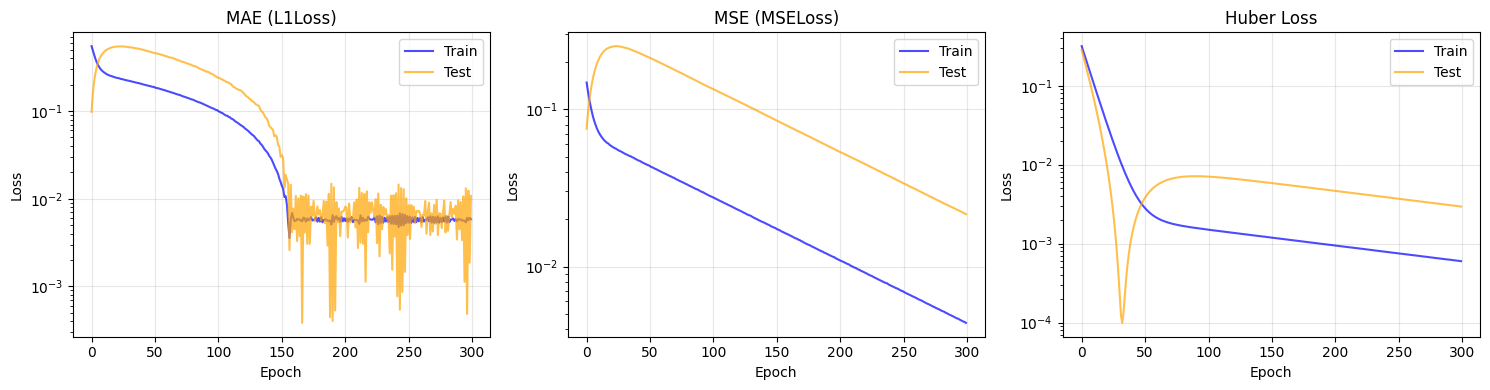

In [14]:
print("\n" + "="*60)
print("COMPARING DIFFERENT LOSS FUNCTIONS")
print("="*60)

def train_with_loss(loss_fn_name, loss_fn, epochs=300):
    """
    Helper function to train a model with a given loss function
    """
    # Create fresh model
    model = LinearRegressionModel()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    
    train_losses = []
    test_losses = []
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            predictions = model(X_batch)
            loss = loss_fn(predictions, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Testing
        model.eval()
        test_loss = 0.0
        with torch.inference_mode():
            for X_batch, y_batch in test_loader:
                predictions = model(X_batch)
                loss = loss_fn(predictions, y_batch)
                test_loss += loss.item()
        
        avg_test_loss = test_loss / len(test_loader)
        test_losses.append(avg_test_loss)
    
    return model, train_losses, test_losses

# Train with different loss functions
print("Training with L1Loss (MAE)...")
model_mae, train_mae, test_mae = train_with_loss("L1Loss", nn.L1Loss())

print("Training with MSELoss...")
model_mse, train_mse, test_mse = train_with_loss("MSELoss", nn.MSELoss())

print("Training with HuberLoss...")
model_huber, train_huber, test_huber = train_with_loss("HuberLoss", HuberLoss(delta=1.0))

# Compare results
print("\n" + "="*60)
print("COMPARISON RESULTS")
print("="*60)

def print_model_params(model, name):
    print(f"{name}:")
    print(f"  Weight: {model.weight.item():.6f} (true: {weight_true})")
    print(f"  Bias: {model.bias.item():.6f} (true: {bias_true})")

print_model_params(model_mae, "MAE (L1Loss)")
print_model_params(model_mse, "MSE (MSELoss)")
print_model_params(model_huber, "Huber Loss")

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

losses = [
    (train_mae, test_mae, "MAE (L1Loss)"),
    (train_mse, test_mse, "MSE (MSELoss)"),
    (train_huber, test_huber, "Huber Loss")
]

for ax, (train, test, title) in zip(axes, losses):
    ax.plot(train, label='Train', color='blue', alpha=0.7)
    ax.plot(test, label='Test', color='orange', alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

plt.tight_layout()
plt.show()

## Summary and Key Takeaways

In [ ]:
print("\n" + "="*60)
print("SUMMARY AND KEY TAKEAWAYS")
print("="*60)

print("""
CONCEPTS COVERED IN THIS NOTEBOOK:
─────────────────────────────────────

1. DATA GENERATION
   ✓ Creating synthetic data with known relationship
   ✓ torch.arange() and tensor operations
   ✓ Using unsqueeze() for proper tensor dimensions

2. DATA PREPARATION
   ✓ Train/test split (80/20 rule)
   ✓ TensorDataset for pairing features and targets
   ✓ DataLoader for batch processing
   ✓ shuffle=True for training, False for testing

3. MODEL DEFINITION
   ✓ Inheriting from nn.Module
   ✓ Using nn.Parameter for learnable parameters
   ✓ Implementing forward() method
   ✓ Understanding requires_grad=True

4. LOSS FUNCTIONS
   ✓ Built-in losses (L1Loss, MSELoss)
   ✓ Custom loss functions (MAE, Huber)
   ✓ Understanding different loss properties

5. OPTIMIZATION
   ✓ SGD optimizer
   ✓ Learning rate selection
   ✓ Understanding model.parameters()

6. TRAINING LOOP
   ✓ model.train() vs model.eval()
   ✓ optimizer.zero_grad() - clear gradients
   ✓ loss.backward() - compute gradients
   ✓ optimizer.step() - update weights
   ✓ Tracking training and test losses

7. EVALUATION
   ✓ torch.inference_mode() for evaluation
   ✓ Computing metrics on test set
   ✓ Visualizing predictions

8. MODEL SAVING/LOADING
   ✓ state_dict() for saving parameters
   ✓ load_state_dict() for loading
   ✓ Path management with pathlib

9. PREDICTIONS
   ✓ Making predictions on new data
   ✓ Evaluating model generalization

─────────────────────────────────────
FINAL MODEL PERFORMANCE:
""")

print(f"True relationship: y = {weight_true:.1f}x + {bias_true:.1f}")
print(f"Learned: y = {model.weight.item():.6f}x + {model.bias.item():.6f}")
print(f"Weight accuracy: {(1 - abs(model.weight.item() - weight_true)/abs(weight_true))*100:.2f}%")
print(f"Bias accuracy: {(1 - abs(model.bias.item() - bias_true)/abs(bias_true))*100:.2f}%")

print("""
─────────────────────────────────────
✓ SUCCESS! The model has learned the 
  underlying linear relationship from data!
""")